In [1]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/lib2/UTR5_zinb_norm_2024-06-04.csv")
df

,seq,cell_type,replicate,1,2,3,4
0,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c1,1,614.0,395.0,685.0,815.0
1,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c17,1,1610.0,1682.0,1173.0,2147.0
2,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c17,2,1832.0,1578.0,1736.0,2054.0
3,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c2,1,1136.0,630.0,616.0,341.0
4,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c2,2,798.0,636.0,433.0,315.0
...,...,...,...,...,...,...,...
97119,GGGGGGCCCTGGGGGGCAGCTGCTGCTTTGGATTTTAATTTCTTTC...,c4,2,403.0,551.0,304.0,227.0
97120,GTTTCTTTCTAGATCTGTGGGGGCTGGGGGAGTGTTCAGAGCTGAC...,c4,2,347.0,633.0,284.0,340.0
97121,TGAGAGCTACTCTGGCTGATTTTTCCCTTCCGGTGAGGTTTGGAGC...,c4,2,335.0,126.0,297.0,133.0
97122,AAAATCAGGATCTCATTACAAGAGCCTTCTATTTTCTTTAACCTCC...,c4,2,772.0,466.0,325.0,127.0


In [3]:
df["seq"] = df["seq"].str.upper()

In [4]:
df = df[df["cell_type"] != "c13"]

In [5]:
df = df.groupby(by=["seq", "cell_type"])[["1", "2", "3", "4"]].sum().reset_index()

In [6]:
ct_counts = df.groupby("seq")["cell_type"].count()
ct_max = ct_counts.max()
ct_counts_seqs = ct_counts[ct_counts == ct_max].index
df = df[df["seq"].isin(ct_counts_seqs)].reset_index(drop=True).copy()

In [7]:
bins = np.arange(1, 5)
cpm = df[["1", "2", "3", "4"]]
mass_center = (cpm * bins).sum(axis=1) / cpm.sum(axis=1)
mass_center

0        2.677959
1        2.569722
2        2.109072
3        1.913060
4        2.214925
           ...   
50865    2.635636
50866    2.506005
50867    2.536861
50868    2.458855
50869    2.313986
Length: 50870, dtype: float64

In [8]:
df.insert(6, "mass_center", mass_center)
df

,seq,cell_type,1,2,3,4,mass_center
0,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c1,614.0,395.0,685.0,815.0,2.677959
1,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c17,3442.0,3260.0,2909.0,4201.0,2.569722
2,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c2,3384.0,2467.0,1713.0,1320.0,2.109072
3,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c4,3926.0,1645.0,1375.0,933.0,1.913060
4,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c6,4475.0,2894.0,3129.0,2018.0,2.214925
...,...,...,...,...,...,...,...
50865,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c1,3743.0,3008.0,4050.0,4807.0,2.635636
50866,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c17,8932.0,12713.0,10469.0,9848.0,2.506005
50867,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c2,9045.0,10634.0,12367.0,9488.0,2.536861
50868,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c4,15230.0,14372.0,13533.0,13944.0,2.458855


In [9]:
mass_center_mean = df.groupby(by=["seq"])["mass_center"].mean().loc[df["seq"]].reset_index(drop=True)
mass_center_mean

0        2.296948
1        2.296948
2        2.296948
3        2.296948
4        2.296948
           ...   
50865    2.490269
50866    2.490269
50867    2.490269
50868    2.490269
50869    2.490269
Name: mass_center, Length: 50870, dtype: float64

In [10]:
mass_center_std = df.groupby(by=["seq"])["mass_center"].std().loc[df["seq"]].reset_index(drop=True)
mass_center_std

0        0.319754
1        0.319754
2        0.319754
3        0.319754
4        0.319754
           ...   
50865    0.117911
50866    0.117911
50867    0.117911
50868    0.117911
50869    0.117911
Name: mass_center, Length: 50870, dtype: float64

In [11]:
df.insert(7, "mass_center_mean", mass_center_mean)
df.insert(8, "mass_center_std", mass_center_std)
df

,seq,cell_type,1,2,3,4,mass_center,mass_center_mean,mass_center_std
0,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c1,614.0,395.0,685.0,815.0,2.677959,2.296948,0.319754
1,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c17,3442.0,3260.0,2909.0,4201.0,2.569722,2.296948,0.319754
2,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c2,3384.0,2467.0,1713.0,1320.0,2.109072,2.296948,0.319754
3,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c4,3926.0,1645.0,1375.0,933.0,1.913060,2.296948,0.319754
4,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c6,4475.0,2894.0,3129.0,2018.0,2.214925,2.296948,0.319754
...,...,...,...,...,...,...,...,...,...
50865,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c1,3743.0,3008.0,4050.0,4807.0,2.635636,2.490269,0.117911
50866,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c17,8932.0,12713.0,10469.0,9848.0,2.506005,2.490269,0.117911
50867,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c2,9045.0,10634.0,12367.0,9488.0,2.536861,2.490269,0.117911
50868,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c4,15230.0,14372.0,13533.0,13944.0,2.458855,2.490269,0.117911


In [12]:
diffs = (df["mass_center"] - df["mass_center_mean"])
zscores = diffs / df["mass_center_std"]

In [13]:
df.insert(8, "diff", diffs)
df.insert(9, "zscore", zscores)
df

,seq,cell_type,1,2,3,4,mass_center,mass_center_mean,diff,zscore,mass_center_std
0,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c1,614.0,395.0,685.0,815.0,2.677959,2.296948,0.381012,1.191578,0.319754
1,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c17,3442.0,3260.0,2909.0,4201.0,2.569722,2.296948,0.272774,0.853076,0.319754
2,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c2,3384.0,2467.0,1713.0,1320.0,2.109072,2.296948,-0.187875,-0.587562,0.319754
3,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c4,3926.0,1645.0,1375.0,933.0,1.913060,2.296948,-0.383888,-1.200572,0.319754
4,AAAAAAAATGTGACGGCGGCGGCGGCGGCGGCGGCGGCAGCGGCGG...,c6,4475.0,2894.0,3129.0,2018.0,2.214925,2.296948,-0.082023,-0.256519,0.319754
...,...,...,...,...,...,...,...,...,...,...,...
50865,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c1,3743.0,3008.0,4050.0,4807.0,2.635636,2.490269,0.145367,1.232848,0.117911
50866,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c17,8932.0,12713.0,10469.0,9848.0,2.506005,2.490269,0.015737,0.133462,0.117911
50867,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c2,9045.0,10634.0,12367.0,9488.0,2.536861,2.490269,0.046593,0.395149,0.117911
50868,TTTTTTGTGTGCGTGCACGTCCTCGTTATCGTGCATCCATGGCGCG...,c4,15230.0,14372.0,13533.0,13944.0,2.458855,2.490269,-0.031413,-0.266416,0.117911


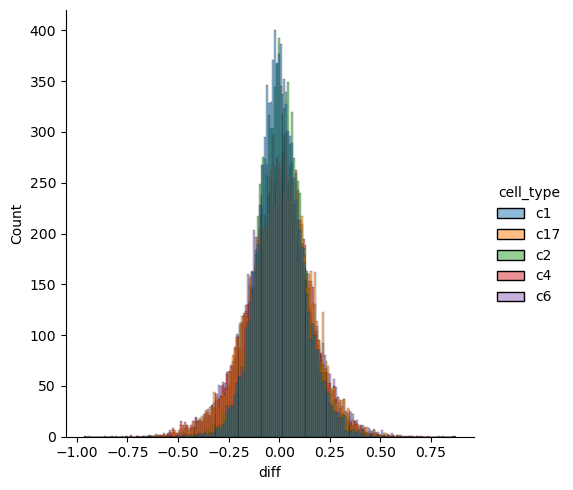

In [14]:
sns.displot(x=df["diff"], hue=df["cell_type"])

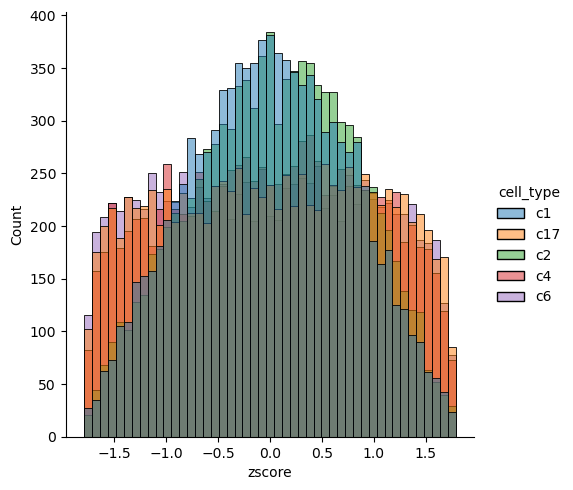

In [15]:
sns.displot(x=df["zscore"], hue=df["cell_type"])

In [16]:
df.to_csv("UTR5_zscores_2024-06-04.csv", index=False)

In [19]:
df['seq'].nunique()

10174